**Problem Statement**

Focus: Class imbalance and pattern recognition.

Fraudulent transactions are rare, often making up less than 1% of total data, leading to a severe class imbalance problem. This project aims to build a predictive model using the Kaggle Fraud Detection dataset to identify hidden patterns in transaction metadata. The objective is to optimize for Recall—ensuring as many fraud cases are caught as possible—while utilizing techniques like SMOTE or cost-sensitive learning to handle the skewed data distribution.

**Data Loading**

In [1]:
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [2]:
df['Class'].value_counts()
#0 - normal, 1 - fraud

,count
Class,
0,284315
1,492


**EDA**

<Axes: xlabel='Class', ylabel='count'>

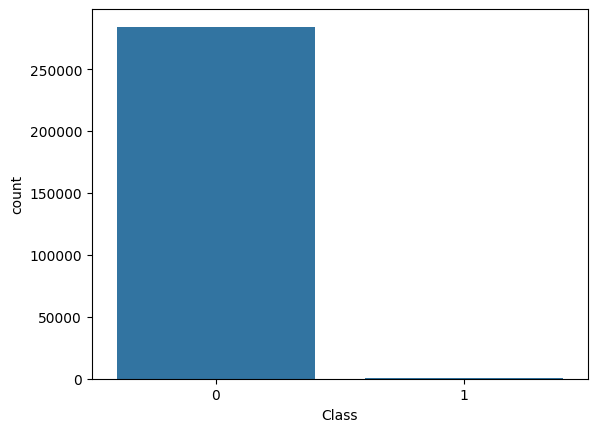

In [3]:
import seaborn as sns
sns.countplot(x='Class', data=df)

<Axes: xlabel='Class', ylabel='Amount'>

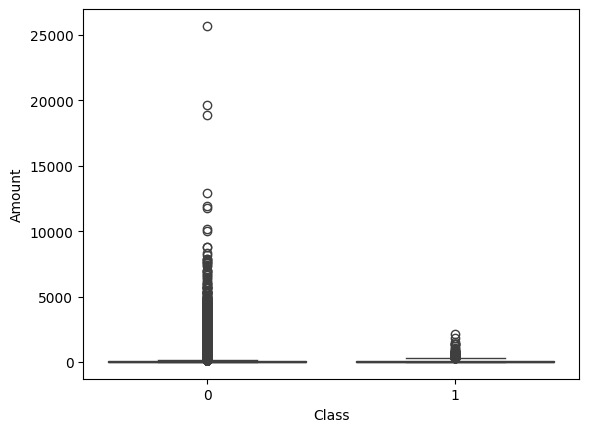

In [4]:
sns.boxplot(x='Class', y='Amount', data=df)

<Axes: xlabel='Time', ylabel='Count'>

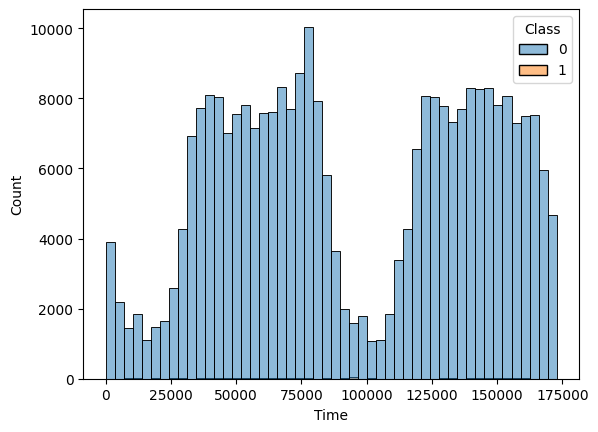

In [5]:
sns.histplot(data=df, x='Time', hue='Class', bins=50)

**Handle imbalance**

In [12]:
fraud =df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(len(fraud), random_state=42)

df_balanced = pd.concat([fraud, normal])

In [15]:
from sklearn.model_selection import train_test_split

X = df_balanced.drop('Class', axis=1)
y = df_balanced['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Model Building**

In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=2000)
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=2000)

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [32]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
V14,0.193416
V10,0.132151
V4,0.123741
V12,0.120383
V17,0.077770
V11,0.049705
V3,0.047252
V16,0.042486
V7,0.039261
V19,0.013945


**Insight**

Certain transaction features contribute more significantly to fraud detection, highlighting patterns in anomalous behavior.

**Evalution**


In [19]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

In [22]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9783998591698918


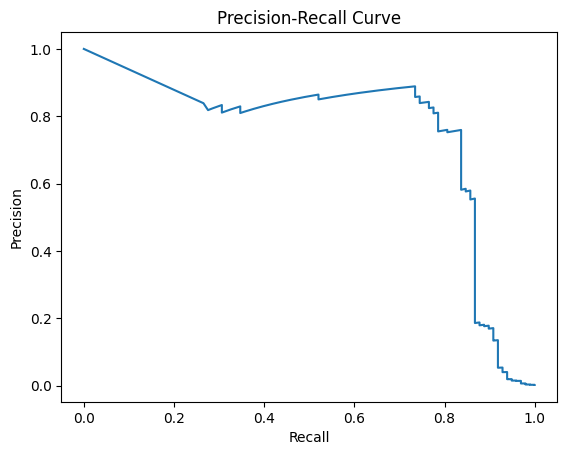

In [27]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

**Insight for Curve**

The Precision-Recall curve highlights the trade-off between detecting fraud and minimizing false positives, which is critical in highly imbalanced datasets.

**Threshold Tuning**

In [29]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-60)
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)

Best Threshold: 0.999997716858436


**Insight for threshold**

Instead of using a default threshold, optimizing based on F1-score improves the balance between precision and recall.

In [30]:
y_pred_custom = (y_prob > 0.3).astype(int)

**Confusion matrix Comparison**

In [31]:
from sklearn.metrics import confusion_matrix
#Default
print("Default Threshold (0.5):")
print(confusion_matrix(y_test, y_pred))

#Custom
print("Optimized Threshold:")
y_pred_opt = (y_prob > best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_opt))

Default Threshold (0.5):
[[55450  1414]
 [    8    90]]
Optimized Threshold:
[[56855     9]
 [   27    71]]


**Insight For Counfusion matrix**

Lowering the threshold increases fraud detection but also raises false positives, demonstrating the trade-off between security and user experience.

**Real-World deployment Considerations**

1. Fraud detection systems must operate in real-time.

2. High recall is prioritized to minimize financial loss.

3. However, excessive false positives can frustrate users.

4. Continuous model monitoring and retraining is essential.

